In [8]:
import sys
path_to_pip_installs = "/tmp/test_env"
if path_to_pip_installs not in sys.path:
    sys.path.insert(0, path_to_pip_installs)

import torch
import numpy as np
import os
from backbones.dense_layer import conv2d
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from dataset.dataset_dixon import CreateDatasetSynthesis_with_masks
from torch.multiprocessing import Process
import torch.distributed as dist
import shutil
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr

from utils.EMA import EMA
from train_utils import sample_from_model, sample_posterior, copy_source, broadcast_params, var_func_vp, var_func_geometric, extract, get_time_schedule, get_sigma_schedule, Diffusion_Coefficients, q_sample, q_sample_pairs, Posterior_Coefficients

from backbones.discriminator import Discriminator_large

from backbones.ncsnpp_generator_adagn_feat import NCSNpp
from backbones.ncsnpp_generator_adagn_feat import NCSNpp_adaptive
from backbones.registration_network import RegistrationUNet

In [6]:
from types import SimpleNamespace

args = SimpleNamespace(
    # Reproducibility
    seed=1024,
    resume=False,

    # Data / images
    image_size=32,
    num_channels=3,
    centered=True,
    use_geometric=False,
    beta_min=0.1,
    beta_max=20.,

    # Denoising model
    num_channels_dae=128,
    n_mlp=3,
    ch_mult=[1, 1, 2, 2, 4, 4],
    num_res_blocks=2,
    attn_resolutions=(16,),
    dropout=0.,
    resamp_with_conv=True,
    conditional=True,
    fir=True,
    fir_kernel=[1, 3, 3, 1],
    skip_rescale=True,
    resblock_type='biggan',
    progressive='none',
    progressive_input='residual',
    progressive_combine='sum',

    embedding_type='positional',
    fourier_scale=16.,
    not_use_tanh=False,

    # Generator & training
    exp='debug',
    input_path='data/my_data2',
    output_path='results',
    nz=100,
    num_timesteps=4,

    z_emb_dim=256,
    t_emb_dim=256,
    batch_size=1,   # good for CPU-only
    num_epoch=1200,
    ngf=64,

    lr_g=1.5e-4,
    lr_d=1e-4,
    beta1=0.5,
    beta2=0.9,
    no_lr_decay=False,

    use_ema=False,
    ema_decay=0.9999,

    r1_gamma=0.05,
    lazy_reg=None,

    save_content=True,
    save_content_every=1,
    save_ckpt_every=10,
    lambda_l1_loss=0.5,
    lambda_mask_loss=0.1,

    # DDP (turned into CPU-only single process)
    num_proc_node=1,
    num_process_per_node=1,   # 1 → no GPU parallelism
    node_rank=0,
    local_rank=0,
    master_address='127.0.0.1',
    contrast1='T1',
    contrast2='T2',
    port_num='6021',

    # Derived
    world_size=1,
    global_rank=0,
)

device = "cpu"
batch_size = args.batch_size
nz = args.nz
rank = 0


to_range_0_1 = lambda x: (x + 1.) / 2.
critic_criterian = nn.BCEWithLogitsLoss(reduction='none')




In [7]:
dataset = CreateDatasetSynthesis_with_masks(phase="train", input_path=args.input_path)
dataset_val = CreateDatasetSynthesis_with_masks(phase="val", input_path=args.input_path)

data_loader = torch.utils.data.DataLoader(dataset,
                                            batch_size=batch_size,
                                            shuffle=False,
                                            num_workers=4,
                                            pin_memory=False,
                                            drop_last=True)

data_loader_val = torch.utils.data.DataLoader(dataset_val,
                                                batch_size=batch_size,
                                                shuffle=False,
                                                num_workers=4,
                                                pin_memory=False,
                                                drop_last=True)

padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0


In [9]:
# override args
exp_path = "results/exp_brats2"
checkpoint_file = os.path.join(exp_path, 'content.pth')
checkpoint = torch.load(checkpoint_file, map_location=device, weights_only=False)
args = checkpoint["args"]

In [10]:
to_range_0_1 = lambda x: (x + 1.) / 2.
critic_criterian = nn.BCEWithLogitsLoss(reduction='none')

gen_diffusive_1 = NCSNpp(args).to(device)
gen_diffusive_2 = NCSNpp_adaptive(args).to(device)

args.num_channels = 1
att_conv = conv2d(64 * 8, 1, 1, padding=0).to(device)

optimizer_att = optim.Adam(att_conv.parameters(), lr=args.lr_g, betas=(args.beta1, args.beta2))

disc_diffusive_2 = Discriminator_large(nc=2, ngf=args.ngf,
                                        t_emb_dim=args.t_emb_dim,
                                        act=nn.LeakyReLU(0.2)).to(device)

optimizer_disc_diffusive_2 = optim.Adam(disc_diffusive_2.parameters(), lr=args.lr_d, betas=(args.beta1, args.beta2))
optimizer_gen_diffusive_1 = optim.Adam(gen_diffusive_1.parameters(), lr=args.lr_g, betas=(args.beta1, args.beta2))
optimizer_gen_diffusive_2 = optim.Adam(gen_diffusive_2.parameters(), lr=args.lr_g, betas=(args.beta1, args.beta2))
scheduler_gen_diffusive_1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_gen_diffusive_1, args.num_epoch,
                                                                        eta_min=1e-5)
scheduler_gen_diffusive_2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_gen_diffusive_2, args.num_epoch,
                                                                        eta_min=1e-5)
scheduler_disc_diffusive_2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_disc_diffusive_2, args.num_epoch,
                                                                        eta_min=1e-5)

reg_net = RegistrationUNet().to(device)
optimizer_reg = optim.Adam(reg_net.parameters(), lr=args.lr_g, betas=(args.beta1, args.beta2)) # Use generator LR for now

exp = args.exp

output_path = args.output_path

exp_path = os.path.join(output_path, exp)

coeff = Diffusion_Coefficients(args, device)
pos_coeff = Posterior_Coefficients(args, device)
T = get_time_schedule(args, device)

global_step, epoch, init_epoch = 0, 0, 0

def _strip_module_prefix(sd):
    # remove a single leading "module." if present
    return { (k[7:] if k.startswith("module.") else k): v for k, v in sd.items() }


In [11]:
exp_path = "results/exp_brats2"
checkpoint_file = os.path.join(exp_path, 'content.pth')
checkpoint = torch.load(checkpoint_file, map_location=device, weights_only=False)
init_epoch = checkpoint['epoch']
epoch = init_epoch
sd1 = _strip_module_prefix(checkpoint['gen_diffusive_1_dict'])
sd2 = _strip_module_prefix(checkpoint['gen_diffusive_2_dict'])
gen_diffusive_1.load_state_dict(sd1)  # keep strict=True by default
gen_diffusive_2.load_state_dict(sd2)

optimizer_gen_diffusive_1.load_state_dict(checkpoint['optimizer_gen_diffusive_1'])
scheduler_gen_diffusive_1.load_state_dict(checkpoint['scheduler_gen_diffusive_1'])
optimizer_gen_diffusive_2.load_state_dict(checkpoint['optimizer_gen_diffusive_2'])
scheduler_gen_diffusive_2.load_state_dict(checkpoint['scheduler_gen_diffusive_2'])

sdD = _strip_module_prefix(checkpoint['disc_diffusive_2_dict'])
disc_diffusive_2.load_state_dict(sdD)
optimizer_disc_diffusive_2.load_state_dict(checkpoint['optimizer_disc_diffusive_2'])
scheduler_disc_diffusive_2.load_state_dict(checkpoint['scheduler_disc_diffusive_2'])

global_step = checkpoint['global_step']
print("=> loaded checkpoint (epoch {})"
        .format(checkpoint['epoch']))

=> loaded checkpoint (epoch 21)


In [26]:
for iteration, (x1, x2, x3, x4, m1, m2, m3, m4) in enumerate(data_loader):
    if iteration > 1:
        break

#### Discriminator

In [27]:
for p in disc_diffusive_2.parameters():
    p.requires_grad = True

disc_diffusive_2.zero_grad()

# sample from p(x_0)
cond_data1 = x1.to(device, non_blocking=True)
cond_data2 = x2.to(device, non_blocking=True)
cond_data3 = x3.to(device, non_blocking=True)
real_data = x4.to(device, non_blocking=True)

t2 = torch.randint(0, args.num_timesteps, (real_data.size(0),), device=device)

x2_t, x2_tp1 = q_sample_pairs(coeff, real_data, t2)
x2_t.requires_grad = True

# train discriminator with real
D2_real, _ = disc_diffusive_2(x2_t, t2, x2_tp1.detach())

errD2_real2 = F.softplus(-D2_real)
errD2_real2 = errD2_real2.mean()
errD_real2 = errD2_real2
errD_real2.backward(retain_graph=True)


grad2_real = torch.autograd.grad(
    outputs=D2_real.sum(), inputs=x2_t, create_graph=True
)[0]
grad2_penalty = (
        grad2_real.view(grad2_real.size(0), -1).norm(2, dim=1) ** 2
).mean()

grad_penalty2 = args.r1_gamma / 2 * grad2_penalty
grad_penalty2.backward()

In [28]:
# train with fake
latent_z2 = torch.randn(batch_size, nz, device=device)
with torch.no_grad():
    x2_0_predict_diff_g1 = gen_diffusive_1(x2_tp1.detach(), cond_data1, cond_data2, cond_data3, t2, latent_z2)

    x2_0_predict_diff_g2 = gen_diffusive_2(x2_tp1.detach(), cond_data1, cond_data2, cond_data3, t2, latent_z2,
                                        x2_0_predict_diff_g1[:, [0], :])

    x2_pos_sample_g1 = sample_posterior(pos_coeff, x2_0_predict_diff_g1[:, [0], :], x2_tp1, t2)

    x2_pos_sample_g2 = sample_posterior(pos_coeff, x2_0_predict_diff_g2[:, [0], :], x2_tp1, t2)

# D output for fake sample x_pos_sample

output2_g1, _ = disc_diffusive_2(x2_pos_sample_g1, t2, x2_tp1.detach())

output2_g2, _ = disc_diffusive_2(x2_pos_sample_g2, t2, x2_tp1.detach())

errD2_fake2_g1 = (F.softplus(output2_g1)).mean()

errD2_fake2_g2 = (F.softplus(output2_g2)).mean()

errD_fake2 = errD2_fake2_g1 + errD2_fake2_g2
errD_fake2.backward()

optimizer_disc_diffusive_2.step()

## Generator

In [15]:
for p in disc_diffusive_2.parameters():
    p.requires_grad = False

cond_data1 = x1.to(device, non_blocking=True)
cond_data2 = x2.to(device, non_blocking=True)
cond_data3 = x3.to(device, non_blocking=True)
real_data = x4.to(device, non_blocking=True)

mask1 = m1.to(device, non_blocking=True)
mask2 = m2.to(device, non_blocking=True)
mask3 = m3.to(device, non_blocking=True)
target_mask = m4.to(device, non_blocking=True)

gen_diffusive_1.zero_grad()
gen_diffusive_2.zero_grad()
# NEW
reg_net.zero_grad()
att_conv.zero_grad()

#### Registration

In [50]:
reg_input = torch.cat([cond_data1, cond_data2, cond_data3, target_mask], dim=1)
flow1, flow2, flow3 = reg_net(reg_input)

# Create sampling grid
B, _, H, W = cond_data1.shape
grid = torch.meshgrid(torch.arange(H, device=device), torch.arange(W, device=device))
grid = torch.stack(grid, dim=0).float()
grid = grid.unsqueeze(0).repeat(B, 1, 1, 1) # Shape: [B, 2, H, W]

# Apply flow to grid. Note: grid_sample expects coordinates in [-1, 1]
def create_warp_grid(flow, grid):
    v_grid = grid + flow
    # Scale grid to [-1, 1]
    v_grid[:, 0, :, :] = 2.0 * v_grid[:, 0, :, :] / max(W - 1, 1) - 1.0
    v_grid[:, 1, :, :] = 2.0 * v_grid[:, 1, :, :] / max(H - 1, 1) - 1.0
    v_grid = v_grid.permute(0, 2, 3, 1) # to [B, H, W, 2]
    return v_grid

def create_warp_grid(flow, H, W, device):
    # Create base grid: x-coordinates vary along columns, y-coordinates along rows
    # torch.arange(W) gives [0, 1, ..., W-1] for X
    # torch.arange(H) gives [0, 1, ..., H-1] for Y
    # meshgrid(X_coords, Y_coords) ensures output[0] are X-coords, output[1] are Y-coords
    mesh_x, mesh_y = torch.meshgrid(torch.arange(W, device=device), torch.arange(H, device=device), indexing='ij')

    # Stack them to get [W, H] for x and [W, H] for y, then reshape to [1, 2, H, W]
    # We want flow to be added to [X, Y] coordinates
    base_grid = torch.stack([mesh_x, mesh_y], dim=0).float().unsqueeze(0) # Shape: [1, 2, W, H]
    # Permute to [1, 2, H, W]
    base_grid = base_grid.permute(0, 1, 3, 2)


    # Flow is typically dx, dy. Add dx to x-coordinates and dy to y-coordinates.
    # Assuming flow channels are (dx, dy)
    # v_grid[:, 0, :, :] are x-offsets, v_grid[:, 1, :, :] are y-offsets
    v_grid_x = base_grid[:, 0, :, :] + flow[:, 0, :, :]
    v_grid_y = base_grid[:, 1, :, :] + flow[:, 1, :, :]

    # Stack back to [B, 2, H, W] where dim 0 is X and dim 1 is Y
    v_grid = torch.stack([v_grid_x, v_grid_y], dim=1)


    # Scale grid to [-1, 1] for grid_sample
    # X coordinates: scale by W
    # Y coordinates: scale by H
    v_grid_scaled_x = 2.0 * v_grid[:, 0, :, :] / max(W - 1, 1) - 1.0
    v_grid_scaled_y = 2.0 * v_grid[:, 1, :, :] / max(H - 1, 1) - 1.0

    v_grid_scaled = torch.stack([v_grid_scaled_x, v_grid_scaled_y], dim=1)

    # Permute to [B, H, W, 2] where the last dim is (x, y)
    v_grid_final = v_grid_scaled.permute(0, 2, 3, 1)
    return v_grid_final

def create_warp_grid_with_base(flow, base_grid_xy, H, W):
    # base_grid_xy is [B, 2, H, W] with base_grid_xy[:,0] as X and base_grid_xy[:,1] as Y
    
    # Add flow offsets to the base coordinates
    # Assuming flow[:,0] is dx and flow[:,1] is dy
    v_grid_x = base_grid_xy[:, 0, :, :] + flow[:, 0, :, :]
    v_grid_y = base_grid_xy[:, 1, :, :] + flow[:, 1, :, :]

    # Stack them back
    v_grid = torch.stack([v_grid_x, v_grid_y], dim=1)

    # Scale grid to [-1, 1] for grid_sample
    v_grid_scaled_x = 2.0 * v_grid[:, 0, :, :] / max(W - 1, 1) - 1.0
    v_grid_scaled_y = 2.0 * v_grid[:, 1, :, :] / max(H - 1, 1) - 1.0
    v_grid_scaled = torch.stack([v_grid_scaled_x, v_grid_scaled_y], dim=1)

    # Permute to [B, H, W, 2] for grid_sample
    v_grid_final = v_grid_scaled.permute(0, 2, 3, 1)
    return v_grid_final


B, _, H, W = cond_data1.shape
x_coords = torch.arange(W, device=device)
y_coords = torch.arange(H, device=device)
# Use indexing='ij' to get (X_grid, Y_grid) from meshgrid
mesh_x, mesh_y = torch.meshgrid(x_coords, y_coords, indexing='ij')

# Stack to get base_grid_xy [W, H] for X and [W, H] for Y
base_grid_xy = torch.stack([mesh_x, mesh_y], dim=0).float() # Shape: [2, W, H]
# Permute to [2, H, W] to match image tensor's (C, H, W) layout for consistency if desired
base_grid_xy = base_grid_xy.permute(0, 2, 1) # Now base_grid_xy[0] is X, base_grid_xy[1] is Y
base_grid_xy = base_grid_xy.unsqueeze(0).repeat(B, 1, 1, 1) # Shape: [B, 2, H, W]

grid1 = create_warp_grid_with_base(flow1, base_grid_xy, H, W)
grid2 = create_warp_grid_with_base(flow2, base_grid_xy, H, W)
grid3 = create_warp_grid_with_base(flow3, base_grid_xy, H, W)

# Warp images and masks
cond1_warped = F.grid_sample(cond_data1, grid1, mode='bilinear', padding_mode='border', align_corners=True)
cond2_warped = F.grid_sample(cond_data2, grid2, mode='bilinear', padding_mode='border', align_corners=True)
cond3_warped = F.grid_sample(cond_data3, grid3, mode='bilinear', padding_mode='border', align_corners=True)

mask1_warped = F.grid_sample(mask1, grid1, mode='nearest', align_corners=True)
mask2_warped = F.grid_sample(mask2, grid2, mode='nearest', align_corners=True)
mask3_warped = F.grid_sample(mask3, grid3, mode='nearest', align_corners=True)


#### Visualization

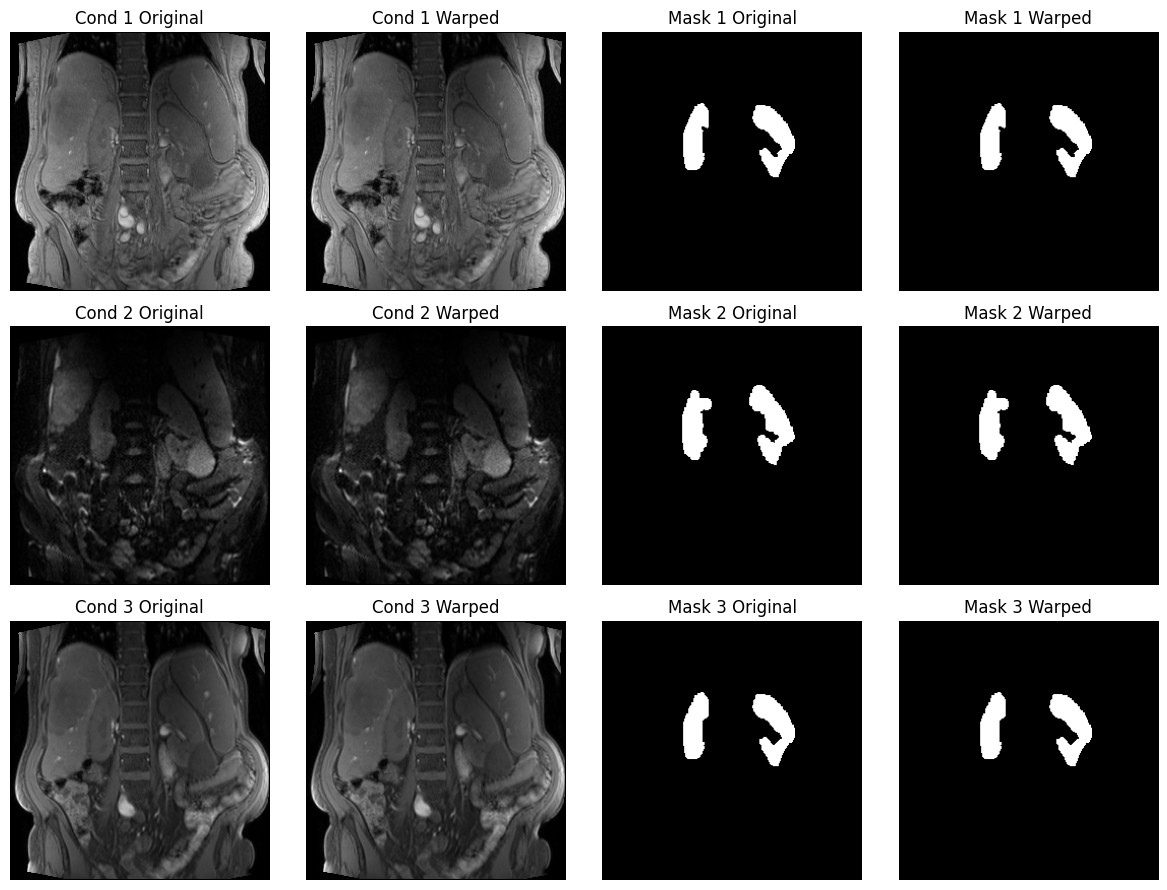

In [51]:
# show images and warped images
fig, ax = plt.subplots(3, 4, figsize=(12, 9))
ax[0, 0].imshow(cond_data1[0, 0].detach().cpu(), cmap='gray')
ax[0, 0].set_title('Cond 1 Original')
ax[0, 1].imshow(cond1_warped[0, 0].detach().cpu(), cmap='gray')
ax[0, 1].set_title('Cond 1 Warped')
ax[0, 2].imshow(mask1[0, 0].detach().cpu(), cmap='gray')
ax[0, 2].set_title('Mask 1 Original')
ax[0, 3].imshow(mask1_warped[0, 0].detach().cpu(), cmap='gray')
ax[0, 3].set_title('Mask 1 Warped')
ax[1, 0].imshow(cond_data2[0, 0].detach().cpu(), cmap='gray')
ax[1, 0].set_title('Cond 2 Original')
ax[1, 1].imshow(cond2_warped[0, 0].detach().cpu(), cmap='gray')
ax[1, 1].set_title('Cond 2 Warped')
ax[1, 2].imshow(mask2[0, 0].detach().cpu(), cmap='gray')
ax[1, 2].set_title('Mask 2 Original')
ax[1, 3].imshow(mask2_warped[0, 0].detach().cpu(), cmap='gray')
ax[1, 3].set_title('Mask 2 Warped')
ax[2, 0].imshow(cond_data3[0, 0].detach().cpu(), cmap='gray')
ax[2, 0].set_title('Cond 3 Original')
ax[2, 1].imshow(cond3_warped[0, 0].detach().cpu(), cmap='gray')
ax[2, 1].set_title('Cond 3 Warped')
ax[2, 2].imshow(mask3[0, 0].detach().cpu(), cmap='gray')
ax[2, 2].set_title('Mask 3 Original')
ax[2, 3].imshow(mask3_warped[0, 0].detach().cpu(), cmap='gray')
ax[2, 3].set_title('Mask 3 Warped')
for a in ax.flatten():
    a.axis('off')
plt.tight_layout()
plt.show()

#### Diffusion Step

In [52]:
t2 = torch.randint(0, args.num_timesteps, (real_data.size(0),), device=device)

# sample x_t and x_tp1
x2_t, x2_tp1 = q_sample_pairs(coeff, real_data, t2)

latent_z2 = torch.randn(batch_size, nz, device=device)

x2_0_predict_diff_g1 = gen_diffusive_1(x2_tp1.detach(), cond1_warped, cond2_warped, cond3_warped, t2, latent_z2)

x2_0_predict_diff_g2 = gen_diffusive_2(x2_tp1.detach(), cond1_warped, cond2_warped, cond3_warped, t2, latent_z2,
                                        x2_0_predict_diff_g1[:, [0], :])

# sampling q(x_t | x_0_predict, x_t+1)
x2_pos_sample_g1 = sample_posterior(pos_coeff, x2_0_predict_diff_g1[:, [0], :], x2_tp1, t2)

x2_pos_sample_g2 = sample_posterior(pos_coeff, x2_0_predict_diff_g2[:, [0], :], x2_tp1, t2)

# D output for fake sample x_pos_sample
output2_g1, att_feat_g1 = disc_diffusive_2(x2_pos_sample_g1, t2, x2_tp1.detach())

output2_g2, att_feat_g2 = disc_diffusive_2(x2_pos_sample_g2, t2, x2_tp1.detach())

att_map_g1 = torch.sigmoid(att_conv(att_feat_g1))
att_map_g1 = F.interpolate(att_map_g1, size=(256, 256), mode='bilinear', align_corners=False)

att_map_g2 = torch.sigmoid(att_conv(att_feat_g2))
att_map_g2 = F.interpolate(att_map_g2, size=(256, 256), mode='bilinear', align_corners=False)

mask_loss_1 = (att_map_g2 * critic_criterian(x2_pos_sample_g1, torch.sigmoid(x2_pos_sample_g2))).mean()
mask_loss_2 = (att_map_g1 * critic_criterian(x2_pos_sample_g2, torch.sigmoid(x2_pos_sample_g1))).mean()

mask_loss = mask_loss_1 + mask_loss_2

errG2 = F.softplus(-output2_g1)
errG2 = errG2.mean()

errG4 = F.softplus(-output2_g2)
errG4 = errG4.mean()

errG_adv = errG2 + errG4

errG1_2_L1 = F.l1_loss(x2_0_predict_diff_g1[:, [0], :], real_data)

errG2_2_L1 = F.l1_loss(x2_0_predict_diff_g2[:, [0], :], real_data)

errG_L1 = errG1_2_L1 + errG2_2_L1

errG = errG_adv + (args.lambda_l1_loss * errG_L1) + (args.lambda_mask_loss * mask_loss)

In [ ]:
# Place this in your train_utils.py or at the top of the train script
def dice_loss(pred, target, smooth=1.):
    target = (target + 1) / 2.0
    pred = (pred + 1) / 2.0
    intersection = (pred * target).sum(dim=(2, 3))
    union = (pred+target).sum(dim=(2, 3))
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1-dice.mean()

def smoothness_loss(flow):
    dy = torch.abs(flow[:, :, 1:, :] - flow[:, :, :-1, :])
    dx = torch.abs(flow[:, :, :, 1:] - flow[:, :, :, :-1])
    return (torch.mean(dx**2) + torch.mean(dy**2)) / 2.0

def dice_coefficient_numpy(y_true, y_pred, smooth=1e-6):
    # transform from -1,1 to 0,1 range
    y_true = (y_true > 0.5).astype(np.float32)
    y_pred = (y_pred > 0.5).astype(np.float32)
    y_true_f = np.reshape(y_true, [-1])
    y_pred_f = np.reshape(y_pred, [-1])
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

loss_reg_dice = (dice_loss(mask1_warped, target_mask) + 
                dice_loss(mask2_warped, target_mask) + 
                dice_loss(mask3_warped, target_mask)) / 3.0

loss_reg_smooth = (smoothness_loss(flow1) + 
                smoothness_loss(flow2) + 
                smoothness_loss(flow3)) / 3.0

tensor(0.7943, grad_fn=<MeanBackward0>)

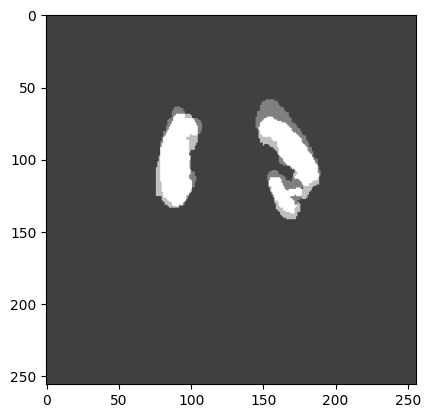

In [129]:
plt.imshow(mask2_warped[0, 0].detach().cpu(), cmap='gray', alpha=0.5)
plt.imshow(target_mask[0, 0].detach().cpu(), cmap='gray', alpha=0.5)
dice_loss(mask2_warped, target_mask)

In [103]:
target = (target_mask + 1) / 2.0
pred = (mask3_warped + 1) / 2.0
#pred = torch.sigmoid(pred) # Assuming network output is logits
intersection = (pred * target).sum(dim=(2, 3))
union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))

1-((2. * intersection + 0.001) / (union + 0.001)).mean()

tensor(0.1311, grad_fn=<RsubBackward1>)

tensor([[0.8689]], grad_fn=<DivBackward0>)


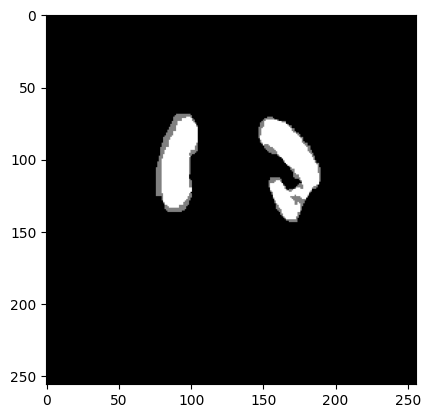

In [124]:
intersection = target*pred
union = pred + target

print(2*intersection.sum(dim=(2,3))/(union+1e-6).sum(dim=(2,3)))

plt.imshow(intersection[0,0].detach().cpu(), cmap='gray')
plt.imshow(union[0,0].detach().cpu(), cmap='gray')

In [111]:
pred * target

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]], grad_fn=<MulBackward0>)